In [4]:
import sys
sys.path.append('../')
import os
import torch
from dotenv import load_dotenv
import LLMP as L

# Clear CUDA cache if using GPU
torch.cuda.empty_cache()

# Set the device to CPU (if needed)
device = torch.device("cpu")

# Load environment variables from the .env file
load_dotenv()

# Create instances of the Gemini models
gpt4vision = L.GPTModel("gpt-4-vision-preview")
gpt4o = L.GPTModel("gpt-4o")
gemini1 = L.GeminiProVision()  
gemini2 = L.Gemini1_5Flash() 

# Add them to a dictionary for easy access
model_instances = {
    "gpt4o": gpt4o,
    "gpt4vision": gpt4vision,
    "LLaVA": L.LLaVA(),  
    "CustomLLaVA": L.CustomLLaVA(),  
    "GeminiProVision": gemini1,  
    "Gemini1_5Flash": gemini2
}

# Define your query and images
query = "What do you see? If you see a circle, can you estimate the area inside of the circle in pixels? (The image itself is 100 by 100 pixels) Please respond with just the range."
images = [L.GPImage.figure1('area') for i in range(10)]

# Run the evaluator
result1 = L.Evaluator.run(images, query, model_instances)
print(result1)


Initializing GPTModel with model_name: gpt-4-vision-preview
Initializing GPTModel with model_name: gpt-4o


/home/huuthanhvy.nguyen001/anaconda3/envs/LLMP/lib/python3.11/site-packages/huggingface_hub/file_download.py:1150: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(
You are using a model of type llava to instantiate a model of type llava_llama. This is not supported for all configurations of models and can yield errors.
Loading checkpoint shards: 100%|█████████████████████████████████████████| 2/2 [00:06<00:00,  3.50s/it]
/home/huuthanhvy.nguyen001/anaconda3/envs/LLMP/lib/python3.11/site-packages/transformers/generation/configuration_utils.py:389: UserWarning: `do_sample` is set to `False`. However, `temperature` is set to `0` -- this flag is only used in sample-based generation modes. You should set `do_sample=True` or unset `temperature`.
  warnings.warn(
/home/huuthanhvy.nguyen001/anaconda3/envs/LLMP/lib/python3.11/site-packages/t

{'gt': [3216.990877275948, 4536.459791783661, 113.09733552923255, 2123.7166338267, 1963.4954084936207, 314.1592653589793, 2290.221044466959, 3216.990877275948, 153.93804002589985, 78.53981633974483], 'gpt4o': {'raw_answers': ['6000-8000 pixels', '7850 to 8000 pixels.', '50 - 100 pixels.', '2000-3000 pixels.', '2000 - 2500 pixels.', '70-100 pixels.', '[2000, 3000] pixels', '7500-8500 pixels', '75 - 85 pixels', '50-70 pixels'], 'parsed_answers': [[6000.0, 8000.0], [7850.0, 8000.0], [50.0, 100.0], [2000.0, 3000.0], [2000.0, 2500.0], [70.0, 100.0], [2000.0, 3000.0], [7500.0, 8500.0], [75.0, 85.0], [50.0, 70.0]], 'mean': 3047.5, 'std': 3170.4638856167403, 'mse': 4899799.62305983, 'mlae': 17.00874289971336, 'times': [1339.0419483184814, 1248.6376762390137, 2734.9629402160645, 936.1879825592041, 1448.3144283294678, 4666.316270828247, 807.4357509613037, 4116.5289878845215, 2731.687307357788, 1349.869966506958], 'forced_repetitions': 0}, 'gpt4vision': {'raw_answers': ['7000-7500 pixels', '7000-

In [1]:
result1={'gt': [3216.990877275948, 4536.459791783661, 113.09733552923255, 2123.7166338267, 1963.4954084936207, 314.1592653589793, 2290.221044466959, 3216.990877275948, 153.93804002589985, 78.53981633974483], 'gpt4o': {'raw_answers': ['6000-8000 pixels', '7850 to 8000 pixels.', '50 - 100 pixels.', '2000-3000 pixels.', '2000 - 2500 pixels.', '70-100 pixels.', '[2000, 3000] pixels', '7500-8500 pixels', '75 - 85 pixels', '50-70 pixels'], 'parsed_answers': [[6000.0, 8000.0], [7850.0, 8000.0], [50.0, 100.0], [2000.0, 3000.0], [2000.0, 2500.0], [70.0, 100.0], [2000.0, 3000.0], [7500.0, 8500.0], [75.0, 85.0], [50.0, 70.0]], 'mean': 3047.5, 'std': 3170.4638856167403, 'mse': 4899799.62305983, 'mlae': 17.00874289971336, 'times': [1339.0419483184814, 1248.6376762390137, 2734.9629402160645, 936.1879825592041, 1448.3144283294678, 4666.316270828247, 807.4357509613037, 4116.5289878845215, 2731.687307357788, 1349.869966506958], 'forced_repetitions': 0}, 'gpt4vision': {'raw_answers': ['7000-7500 pixels', '7000-7500 pixels', '600-700', '3000-3500', "I see a circle. Without an exact measurement of the circle's diameter, it is quite difficult to estimate its area in pixels accurately. However, by visually estimating the circle's diameter relative to the 100x100 pixel image, it appears to take up less than half of the image's width and height.\n\nGiven that a full 100x100 image comprises 10,000 pixels and the circle's diameter seems to be less than 50 pixels, the area of the circle would be less than π * (50/2)^2 ≈ 1,963 pixels.\n\nThus, we can roughly estimate the range of the pixel area of the circle to be within 0-1,963 pixels, keeping in mind that this is a very rough estimate.", 'I see a circle. To estimate the area in pixels, we could use the formula for the area of a circle A = πr^2, where r is the radius. However, without specific measurements for the radius and not being able to calculate directly using pixels as units of measure, I cannot provide an accurate range for the area inside the circle in pixels.', "The circle appears to take up a significant portion of the image but is not touching the edges. Assuming the image is 100 by 100 pixels and that the circle looks to be approximately 80% of the image's width or height, its diameter could be around 80 pixels. The area A of a circle is calculated using the formula A = πr², where r is the radius of the circle. If the diameter is 80 pixels, the radius r would be 40 pixels.\n\nCalculating the area:\nA = π(40 pixels)²\nA ≈ 3.14159 × 1600 pixels²\n\nThe estimated area would be approximately:\nA ≈ 5026.55 pixels²\n\nSo the range for the circle's area in pixels would approximately be:\n5000-5100 pixels²", '7000-8000', '200-300', '75-125 pixels'], 'parsed_answers': [[7000.0, 7500.0], [7000.0, 7500.0], [600.0, 700.0], [3000.0, 3500.0], [0.0, 1.0, 963.0], [2.0], [5000.0, 5100.0], [7000.0, 8000.0], [200.0, 300.0], [75.0, 125.0]], 'mean': 3178.4, 'std': 3116.810266923542, 'mse': 5344774.925833112, 'mlae': 17.405715936268017, 'times': [1286.6425514221191, 1426.196813583374, 33574.49650764465, 1269.000768661499, 4976.963520050049, 3196.7642307281494, 6438.947916030884, 1633.573293685913, 1207.974910736084, 1041.5220260620117], 'forced_repetitions': 13}, 'LLaVA': {'raw_answers': ['Yes, I see a circle. The area inside the circle is approximately 50 pixels.', 'Yes, I see a circle. The area inside the circle is approximately 50 pixels.', 'Yes, I see a circle in the image. The area inside the circle is approximately 10 by 10 pixels.', 'Yes, I see a circle. The area inside the circle is approximately 50 pixels.', 'Yes, I see a circle. The area inside the circle is approximately 100 by 100 pixels.', 'Yes, I see a circle. The area inside the circle is approximately 100 by 100 pixels.', 'Yes, I see a circle. The area inside the circle is approximately 50 pixels.', 'Yes, I see a circle. The area inside the circle is approximately 50 pixels.', 'Yes, I see a circle in the image. The area inside the circle is approximately 100 by 100 pixels.', 'Yes, I see a circle in the image. The area inside the circle is approximately 100 by 100 pixels.'], 'parsed_answers': [[50.0], [50.0], [10.0, 10.0], [50.0], [100.0, 100.0], [100.0, 100.0], [50.0], [50.0], [100.0, 100.0], [100.0, 100.0]], 'mean': 66.0, 'std': 30.066592756745816, 'mse': 5303935.314292552, 'mlae': 17.407943367834548, 'times': [9919.581651687622, 8064.881086349487, 12603.029727935791, 14754.805564880371, 8279.616117477417, 8235.527992248535, 8456.883430480957, 8221.479177474976, 8287.725448608398, 8267.315149307251], 'forced_repetitions': 0}, 'CustomLLaVA': {'raw_answers': ['1000.45366959', '1385.442360233099', '1000.9291584566666', '1385.442360233099', '1000.9291584566666', '314.1592653589793', '3216.990877275948', '1000.9291584566666', '1000.9291584566666', '3631.6811075498013'], 'parsed_answers': [[1000.45366959], [1385.442360233099], [1000.9291584566666], [1385.442360233099], [1000.9291584566666], [314.1592653589793], [3216.990877275948], [1000.9291584566666], [1000.9291584566666], [3631.6811075498013]], 'mean': 1493.7886274067594, 'std': 1008.4659000071208, 'mse': 3621381.4936178275, 'mlae': 17.241834547194344, 'times': [9853.041172027588, 10173.444271087646, 10173.015832901001, 9843.092679977417, 9988.124370574951, 9916.983366012573, 10020.679473876953, 10125.452041625977, 9993.027687072754, 10112.772703170776], 'forced_repetitions': 0}, 'GeminiProVision': {'raw_answers': ['6000-8000 pixels \n', '7000-8000 pixels \n', '2500-5000 pixels \n', '7500-8500 \n', '4900-5100 \n', '4900-5100 \n', '6000-7000 pixels \n', '6000-7000 \n', '4000-5000 \n', '4900-5100  \n'], 'parsed_answers': [[6000.0, 8000.0], [7000.0, 8000.0], [2500.0, 5000.0], [7500.0, 8500.0], [4900.0, 5100.0], [4900.0, 5100.0], [6000.0, 7000.0], [6000.0, 7000.0], [4000.0, 5000.0], [4900.0, 5100.0]], 'mean': 5875.0, 'std': 1338.1423691072637, 'mse': 17363837.195701372, 'mlae': 18.636171562371235, 'times': [911.5786552429199, 709.7976207733154, 764.3043994903564, 722.1660614013672, 797.6031303405762, 766.0226821899414, 777.5115966796875, 828.5002708435059, 719.1755771636963, 784.6622467041016], 'forced_repetitions': 0}, 'Gemini1_5Flash': {'raw_answers': ['500-1000 \n', '1000-2000 \n', '1000-2000 \n', '2000-3000 \n', '1000-2000 pixels \n', '700-1000 \n', '1000-2000 \n', '6000-7000 \n', '400-500 \n', '1000-2000 \n'], 'parsed_answers': [[500.0, 1000.0], [1000.0, 2000.0], [1000.0, 2000.0], [2000.0, 3000.0], [1000.0, 2000.0], [700.0, 1000.0], [1000.0, 2000.0], [6000.0, 7000.0], [400.0, 500.0], [1000.0, 2000.0]], 'mean': 1855.0, 'std': 1637.9026222581122, 'mse': 3138397.34515347, 'mlae': 17.100902281009486, 'times': [411.14163398742676, 385.97750663757324, 373.10051918029785, 365.2071952819824, 304.00657653808594, 314.6023750305176, 336.41505241394043, 360.5031967163086, 324.8932361602783, 320.41049003601074], 'forced_repetitions': 0}}

In [1]:
import sys
sys.path.append('../')
import os
import torch
from dotenv import load_dotenv
import LLMP as L

# Clear CUDA cache if using GPU
torch.cuda.empty_cache()

# Set the device to CPU (if needed)
device = torch.device("cpu")

# Load environment variables from the .env file
load_dotenv()

# Create instances of the Gemini models
gpt4vision = L.GPTModel("gpt-4-turbo")
gpt4o = L.GPTModel("gpt-4o")
gemini1 = L.GeminiProVision()  
gemini2 = L.Gemini1_5Flash() 

# Add them to a dictionary for easy access
model_instances = {
    "gpt4o": gpt4o,
    "gpt4vision": gpt4vision,
    "LLaVA": L.LLaVA(),  
    "CustomLLaVA": L.CustomLLaVA(),  
    "GeminiProVision": gemini1,  
    "Gemini1_5Flash": gemini2
}

# Define your query and images
query = "What do you see? If you see a circle, can you estimate the area inside of the circle in pixels? (The image itself is 100 by 100 pixels) Please respond with just the range."
images = [L.GPImage.figure1('area') for i in range(10)]

# Run the evaluator
result2 = L.Evaluator.run(images, query, model_instances)
print(result2)


/home/huuthanhvy.nguyen001/anaconda3/envs/LLMP/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


[2024-08-25 15:27:51,833] [INFO] [real_accelerator.py:191:get_accelerator] Setting ds_accelerator to cuda (auto detect)
Initializing GPTModel with model_name: gpt-4-turbo
Initializing GPTModel with model_name: gpt-4o


/home/huuthanhvy.nguyen001/anaconda3/envs/LLMP/lib/python3.11/site-packages/huggingface_hub/file_download.py:1150: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(
You are using a model of type llava to instantiate a model of type llava_llama. This is not supported for all configurations of models and can yield errors.
Loading checkpoint shards: 100%|█| 2/2 [00:05<00:00,  
/home/huuthanhvy.nguyen001/anaconda3/envs/LLMP/lib/python3.11/site-packages/transformers/generation/configuration_utils.py:389: UserWarning: `do_sample` is set to `False`. However, `temperature` is set to `0` -- this flag is only used in sample-based generation modes. You should set `do_sample=True` or unset `temperature`.
  warnings.warn(
/home/huuthanhvy.nguyen001/anaconda3/envs/LLMP/lib/python3.11/site-packages/transformers/generation/configuration_utils.py:394

{'gt': [113.09733552923255, 5026.548245743669, 1809.5573684677208, 2463.0086404143976, 3216.990877275948, 2290.221044466959, 804.247719318987, 2642.079421669016, 380.1327110843649, 12.566370614359172], 'gpt4o': {'raw_answers': ['20-40 pixels', '7500 to 8000 pixels.', '750 to 1250 pixels.', '2000 - 2500 pixels.', 'Approximately 4800 - 5200 pixels.', '700-900 pixels', '700 to 900 pixels', '7500 to 8000 pixels.', '160 - 190 pixels', '0 to 50 pixels squared.'], 'parsed_answers': [[20.0, 40.0], [7500.0, 8000.0], [750.0, 1250.0], [2000.0, 2500.0], [4800.0, 5200.0], [700.0, 900.0], [700.0, 900.0], [7500.0, 8000.0], [160.0, 190.0], [0.0, 50.0]], 'mean': 2558.0, 'std': 2950.695002876441, 'mse': 3965783.5433707973, 'mlae': 16.923709606450345, 'times': [5893.200635910034, 5692.809104919434, 5784.991025924683, 5625.840425491333, 5766.6144371032715, 5703.113079071045, 5822.648048400879, 5718.20330619812, 5834.136486053467, 6285.724401473999], 'forced_repetitions': 0}, 'gpt4vision': {'raw_answers': 

In [1]:
import sys
sys.path.append('../')
import os
import torch
from dotenv import load_dotenv
import LLMP as L

# Clear CUDA cache if using GPU
torch.cuda.empty_cache()

# Set the device to CPU (if needed)
device = torch.device("cpu")

# Load environment variables from the .env file
load_dotenv()

# Create instances of the Gemini models
gpt4vision = L.GPTModel("gpt-4-vision-preview")
gpt4o = L.GPTModel("gpt-4o")
gemini1 = L.GeminiProVision()  
gemini2 = L.Gemini1_5Flash() 

# Add them to a dictionary for easy access
model_instances = {
    "gpt4o": gpt4o,
    "gpt4vision": gpt4vision,
    "LLaVA": L.LLaVA(),  
    "CustomLLaVA": L.CustomLLaVA(),  
    "GeminiProVision": gemini1,  
    "Gemini1_5Flash": gemini2
}

# Define your query and images
query = "What do you see? If you see a circle, can you estimate the area inside of the circle in pixels? (The image itself is 100 by 100 pixels) Please respond with just the range."
images = [L.GPImage.figure1('area') for i in range(10)]

# Run the evaluator
result3 = L.Evaluator.run(images, query, model_instances)
print(result3)

/home/huuthanhvy.nguyen001/anaconda3/envs/LLMP/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


[2024-08-14 21:11:41,208] [INFO] [real_accelerator.py:191:get_accelerator] Setting ds_accelerator to cuda (auto detect)
Initializing GPTModel with model_name: gpt-4-vision-preview
Initializing GPTModel with model_name: gpt-4o


/home/huuthanhvy.nguyen001/anaconda3/envs/LLMP/lib/python3.11/site-packages/huggingface_hub/file_download.py:1150: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(
You are using a model of type llava to instantiate a model of type llava_llama. This is not supported for all configurations of models and can yield errors.
Loading checkpoint shards: 100%|█████████████████████████████████████████| 2/2 [00:13<00:00,  6.90s/it]
/home/huuthanhvy.nguyen001/anaconda3/envs/LLMP/lib/python3.11/site-packages/transformers/generation/configuration_utils.py:389: UserWarning: `do_sample` is set to `False`. However, `temperature` is set to `0` -- this flag is only used in sample-based generation modes. You should set `do_sample=True` or unset `temperature`.
  warnings.warn(
/home/huuthanhvy.nguyen001/anaconda3/envs/LLMP/lib/python3.11/site-packages/t

{'gt': [3.141592653589793, 1809.5573684677208, 314.1592653589793, 4778.362426110075, 1017.8760197630929, 113.09733552923255, 2642.079421669016, 2123.7166338267, 78.53981633974483, 1134.1149479459152], 'gpt4o': {'raw_answers': ['79 to 81 pixels.', '314-317 pixels', 'The area is approximately 78 pixels.', 'Approximately 1,020 to 1,050 pixels.', 'Approximately 282 pixels.', 'The area is approximately 50 to 55 pixels.', 'Approximately 314 pixels.', 'The area inside the circle is approximately 707 pixels.', 'Approximately 50 to 60 pixels.', '201-207 pixels.'], 'parsed_answers': [[79.0, 81.0], [314.0, 317.0], [78.0], [1.0, 20.0, 1.0, 50.0], [282.0], [50.0, 55.0], [314.0], [707.0], [50.0, 60.0], [201.0, 207.0]], 'mean': 212.4, 'std': 196.86261707089034, 'mse': 3362178.05212894, 'mlae': 16.877999903697983, 'times': [1576.216220855713, 1405.5614471435547, 1031.2788486480713, 978.1875610351562, 939.1920566558838, 1125.2176761627197, 1142.6491737365723, 822.8676319122314, 1233.666181564331, 1014.

In [1]:
result1={'gt': [3216.990877275948, 4536.459791783661, 113.09733552923255, 2123.7166338267, 1963.4954084936207, 314.1592653589793, 2290.221044466959, 3216.990877275948, 153.93804002589985, 78.53981633974483], 'gpt4o': {'raw_answers': ['6000-8000 pixels', '7850 to 8000 pixels.', '50 - 100 pixels.', '2000-3000 pixels.', '2000 - 2500 pixels.', '70-100 pixels.', '[2000, 3000] pixels', '7500-8500 pixels', '75 - 85 pixels', '50-70 pixels'], 'parsed_answers': [[6000.0, 8000.0], [7850.0, 8000.0], [50.0, 100.0], [2000.0, 3000.0], [2000.0, 2500.0], [70.0, 100.0], [2000.0, 3000.0], [7500.0, 8500.0], [75.0, 85.0], [50.0, 70.0]], 'mean': 3047.5, 'std': 3170.4638856167403, 'mse': 4899799.62305983, 'mlae': 17.00874289971336, 'times': [1339.0419483184814, 1248.6376762390137, 2734.9629402160645, 936.1879825592041, 1448.3144283294678, 4666.316270828247, 807.4357509613037, 4116.5289878845215, 2731.687307357788, 1349.869966506958], 'forced_repetitions': 0}, 'gpt4vision': {'raw_answers': ['7000-7500 pixels', '7000-7500 pixels', '600-700', '3000-3500', "I see a circle. Without an exact measurement of the circle's diameter, it is quite difficult to estimate its area in pixels accurately. However, by visually estimating the circle's diameter relative to the 100x100 pixel image, it appears to take up less than half of the image's width and height.\n\nGiven that a full 100x100 image comprises 10,000 pixels and the circle's diameter seems to be less than 50 pixels, the area of the circle would be less than π * (50/2)^2 ≈ 1,963 pixels.\n\nThus, we can roughly estimate the range of the pixel area of the circle to be within 0-1,963 pixels, keeping in mind that this is a very rough estimate.", 'I see a circle. To estimate the area in pixels, we could use the formula for the area of a circle A = πr^2, where r is the radius. However, without specific measurements for the radius and not being able to calculate directly using pixels as units of measure, I cannot provide an accurate range for the area inside the circle in pixels.', "The circle appears to take up a significant portion of the image but is not touching the edges. Assuming the image is 100 by 100 pixels and that the circle looks to be approximately 80% of the image's width or height, its diameter could be around 80 pixels. The area A of a circle is calculated using the formula A = πr², where r is the radius of the circle. If the diameter is 80 pixels, the radius r would be 40 pixels.\n\nCalculating the area:\nA = π(40 pixels)²\nA ≈ 3.14159 × 1600 pixels²\n\nThe estimated area would be approximately:\nA ≈ 5026.55 pixels²\n\nSo the range for the circle's area in pixels would approximately be:\n5000-5100 pixels²", '7000-8000', '200-300', '75-125 pixels'], 'parsed_answers': [[7000.0, 7500.0], [7000.0, 7500.0], [600.0, 700.0], [3000.0, 3500.0], [0.0, 1.0, 963.0], [2.0], [5000.0, 5100.0], [7000.0, 8000.0], [200.0, 300.0], [75.0, 125.0]], 'mean': 3178.4, 'std': 3116.810266923542, 'mse': 5344774.925833112, 'mlae': 17.405715936268017, 'times': [1286.6425514221191, 1426.196813583374, 33574.49650764465, 1269.000768661499, 4976.963520050049, 3196.7642307281494, 6438.947916030884, 1633.573293685913, 1207.974910736084, 1041.5220260620117], 'forced_repetitions': 13}, 'LLaVA': {'raw_answers': ['Yes, I see a circle. The area inside the circle is approximately 50 pixels.', 'Yes, I see a circle. The area inside the circle is approximately 50 pixels.', 'Yes, I see a circle in the image. The area inside the circle is approximately 10 by 10 pixels.', 'Yes, I see a circle. The area inside the circle is approximately 50 pixels.', 'Yes, I see a circle. The area inside the circle is approximately 100 by 100 pixels.', 'Yes, I see a circle. The area inside the circle is approximately 100 by 100 pixels.', 'Yes, I see a circle. The area inside the circle is approximately 50 pixels.', 'Yes, I see a circle. The area inside the circle is approximately 50 pixels.', 'Yes, I see a circle in the image. The area inside the circle is approximately 100 by 100 pixels.', 'Yes, I see a circle in the image. The area inside the circle is approximately 100 by 100 pixels.'], 'parsed_answers': [[50.0], [50.0], [10.0, 10.0], [50.0], [100.0, 100.0], [100.0, 100.0], [50.0], [50.0], [100.0, 100.0], [100.0, 100.0]], 'mean': 66.0, 'std': 30.066592756745816, 'mse': 5303935.314292552, 'mlae': 17.407943367834548, 'times': [9919.581651687622, 8064.881086349487, 12603.029727935791, 14754.805564880371, 8279.616117477417, 8235.527992248535, 8456.883430480957, 8221.479177474976, 8287.725448608398, 8267.315149307251], 'forced_repetitions': 0}, 'CustomLLaVA': {'raw_answers': ['1000.45366959', '1385.442360233099', '1000.9291584566666', '1385.442360233099', '1000.9291584566666', '314.1592653589793', '3216.990877275948', '1000.9291584566666', '1000.9291584566666', '3631.6811075498013'], 'parsed_answers': [[1000.45366959], [1385.442360233099], [1000.9291584566666], [1385.442360233099], [1000.9291584566666], [314.1592653589793], [3216.990877275948], [1000.9291584566666], [1000.9291584566666], [3631.6811075498013]], 'mean': 1493.7886274067594, 'std': 1008.4659000071208, 'mse': 3621381.4936178275, 'mlae': 17.241834547194344, 'times': [9853.041172027588, 10173.444271087646, 10173.015832901001, 9843.092679977417, 9988.124370574951, 9916.983366012573, 10020.679473876953, 10125.452041625977, 9993.027687072754, 10112.772703170776], 'forced_repetitions': 0}, 'GeminiProVision': {'raw_answers': ['6000-8000 pixels \n', '7000-8000 pixels \n', '2500-5000 pixels \n', '7500-8500 \n', '4900-5100 \n', '4900-5100 \n', '6000-7000 pixels \n', '6000-7000 \n', '4000-5000 \n', '4900-5100  \n'], 'parsed_answers': [[6000.0, 8000.0], [7000.0, 8000.0], [2500.0, 5000.0], [7500.0, 8500.0], [4900.0, 5100.0], [4900.0, 5100.0], [6000.0, 7000.0], [6000.0, 7000.0], [4000.0, 5000.0], [4900.0, 5100.0]], 'mean': 5875.0, 'std': 1338.1423691072637, 'mse': 17363837.195701372, 'mlae': 18.636171562371235, 'times': [911.5786552429199, 709.7976207733154, 764.3043994903564, 722.1660614013672, 797.6031303405762, 766.0226821899414, 777.5115966796875, 828.5002708435059, 719.1755771636963, 784.6622467041016], 'forced_repetitions': 0}, 'Gemini1_5Flash': {'raw_answers': ['500-1000 \n', '1000-2000 \n', '1000-2000 \n', '2000-3000 \n', '1000-2000 pixels \n', '700-1000 \n', '1000-2000 \n', '6000-7000 \n', '400-500 \n', '1000-2000 \n'], 'parsed_answers': [[500.0, 1000.0], [1000.0, 2000.0], [1000.0, 2000.0], [2000.0, 3000.0], [1000.0, 2000.0], [700.0, 1000.0], [1000.0, 2000.0], [6000.0, 7000.0], [400.0, 500.0], [1000.0, 2000.0]], 'mean': 1855.0, 'std': 1637.9026222581122, 'mse': 3138397.34515347, 'mlae': 17.100902281009486, 'times': [411.14163398742676, 385.97750663757324, 373.10051918029785, 365.2071952819824, 304.00657653808594, 314.6023750305176, 336.41505241394043, 360.5031967163086, 324.8932361602783, 320.41049003601074], 'forced_repetitions': 0}}

result2={'gt': [113.09733552923255, 5026.548245743669, 1809.5573684677208, 2463.0086404143976, 3216.990877275948, 2290.221044466959, 804.247719318987, 2642.079421669016, 380.1327110843649, 12.566370614359172], 'gpt4o': {'raw_answers': ['20-40 pixels', '7500 to 8000 pixels.', '750 to 1250 pixels.', '2000 - 2500 pixels.', 'Approximately 4800 - 5200 pixels.', '700-900 pixels', '700 to 900 pixels', '7500 to 8000 pixels.', '160 - 190 pixels', '0 to 50 pixels squared.'], 'parsed_answers': [[20.0, 40.0], [7500.0, 8000.0], [750.0, 1250.0], [2000.0, 2500.0], [4800.0, 5200.0], [700.0, 900.0], [700.0, 900.0], [7500.0, 8000.0], [160.0, 190.0], [0.0, 50.0]], 'mean': 2558.0, 'std': 2950.695002876441, 'mse': 3965783.5433707973, 'mlae': 16.923709606450345, 'times': [5893.200635910034, 5692.809104919434, 5784.991025924683, 5625.840425491333, 5766.6144371032715, 5703.113079071045, 5822.648048400879, 5718.20330619812, 5834.136486053467, 6285.724401473999], 'forced_repetitions': 0}, 'gpt4vision': {'raw_answers': ['The shape in the image is not a perfect circle but looks more like a hexagon or octagon. However, if your intent is still to estimate the area within this shape assuming it represents a circle in rough terms, I can help with an approximate area in pixels.\n\nObserving the shape, it appears to approximately have a diameter of around 10 pixels. The area \\( A \\) of a circle is calculated using the formula \\( A = \\pi r^2 \\), where \\( r \\) is the radius.\n\nGiven the diameter is about 10 pixels, the radius would be approximately 5 pixels. Plugging this into the formula gives:\n\\[ A = \\pi (5^2) \\]\n\\[ A = 25\\pi \\]\n\\[ A \\approx 78.5 \\, \\text{pixels} \\]\n\nThus, the rough range for the area inside the shape (treated as a circle) would be around 75 to 80 pixels.', 'The area inside the circle is likely in the range of 7000 to 8000 pixels.', "The circle appears to have a diameter that roughly spans about 80% of the image's width, which is 100 pixels. Therefore, the diameter is approximately 80 pixels. \n\nThe radius would be half of the diameter, so about 40 pixels. \n\nThe area \\( A \\) of a circle is given by \\( A = \\pi r^2 \\), where \\( r \\) is the radius. Plugging in our estimated radius:\n\n\\[ A = \\pi \\times (40)^2 \\approx \\pi \\times 1600 \\approx 5026.55 \\text{ square pixels} \\]\n\nHowever, since your request mentions providing just a range, an approximation would place the area of the circle approximately within the range of 4800 to 5200 square pixels.", 'The area inside the circle is approximately in the range of 4900 to 5100 pixels.', 'The range of the estimated area inside the circle in pixels is 2000-3000 pixels.', 'The circle appears to occupy a significant portion of the 100x100 pixel image. Estimating visually, the diameter of the circle looks to be around 80 pixels.\n\nUsing the diameter to calculate the radius as half the diameter (40 pixels), the area \\( A \\) of the circle can be approximated using the formula \\( A = \\pi r^2 \\). Plugging in the radius:\n\\[ A = \\pi \\times 40^2 \\approx 5026.55 \\text{ square pixels} \\]\n\nSo, the estimated area inside the circle is within the range of approximately 5000 to 5100 square pixels.', 'The area inside the circle is approximately in the range of 1500 to 2000 pixels.', 'From the image, the circle appears to approximately fill the majority of the space while staying well within the bounds of the 100 by 100 pixel image. Given this, we can estimate the diameter to be roughly around 80 pixels:\n\n- Radius \\( r \\) approximately \\( \\frac{80}{2} = 40 \\) pixels.\n- Area \\( A \\) can be calculated using the formula \\( A = \\pi r^2 \\approx 3.14 \\times 40^2 \\approx 5024 \\) square pixels.\n\nThus, the estimated range for the area inside the circle is around 5000 square pixels.', 'The area inside the circle in this image is likely within the range of 200 to 300 square pixels.', 'The area inside of the circle in the image is within the range of 20 to 28 pixels.'], 'parsed_answers': [[10.0, 2.0, 10.0, 5.0, 5.0, 2.0, 25.0, 78.5, 75.0, 80.0], [7000.0, 8000.0], [80.0, 100.0, 80.0, 40.0, 2.0, 40.0, 2.0, 1600.0, 5026.55, 4800.0, 5200.0], [4900.0, 5100.0], [2000.0, 3000.0], [80.0, 40.0, 2.0, 40.0, 2.0, 5026.55, 5000.0, 5100.0], [1500.0, 2000.0], [100.0, 100.0, 80.0, 80.0, 2.0, 40.0, 2.0, 3.14, 40.0, 2.0, 5024.0, 5000.0], [200.0, 300.0], [20.0, 28.0]], 'mean': 3853.737, 'std': 3162.370367729877, 'mse': 9395416.650696184, 'mlae': 17.712176328746683, 'times': [62450.841665267944, 6513.844728469849, 10872.851610183716, 6191.491603851318, 6904.356479644775, 9791.196346282959, 6185.224771499634, 9515.947580337524, 6529.169321060181, 6246.565103530884], 'forced_repetitions': 8}, 'LLaVA': {'raw_answers': ['Yes, I see a circle in the image. The area inside the circle is approximately 10 by 10 pixels.', 'Yes, I see a circle. The area inside the circle is approximately 50 pixels.', 'Yes, I see a circle. The area inside the circle is approximately 100 by 100 pixels.', 'Yes, I see a circle. The area inside the circle is approximately 50 pixels.', 'Yes, I see a circle. The area inside the circle is approximately 50 pixels.', 'Yes, I see a circle. The area inside the circle is approximately 50 pixels.', 'Yes, I see a circle. The area inside the circle is approximately 100 by 100 pixels.', 'Yes, I see a circle. The area inside the circle is approximately 50 pixels.', 'Yes, I see a circle. The area inside the circle is approximately 100 by 100 pixels.', 'Yes, I see a circle. The area inside the circle is approximately 100 by 100 pixels.'], 'parsed_answers': [[10.0, 10.0], [50.0], [100.0, 100.0], [50.0], [50.0], [50.0], [100.0, 100.0], [50.0], [100.0, 100.0], [100.0, 100.0]], 'mean': 66.0, 'std': 30.066592756745816, 'mse': 5587123.969619915, 'mlae': 17.479379998709867, 'times': [14036.161422729492, 11612.080812454224, 11564.959526062012, 11376.313924789429, 11311.26856803894, 11324.133396148682, 11631.800174713135, 11259.227991104126, 11286.519765853882, 11304.567813873291], 'forced_repetitions': 0}, 'CustomLLaVA': {'raw_answers': ['1000.9291584566666', '3216.990877275948', '216', '1000.9291584566666', '4096.459791783661', '1385.442360233099', '1000.9291584566666', '314.1592653589793', '12.566370614359172', '1000.7521601035994'], 'parsed_answers': [[1000.9291584566666], [3216.990877275948], [216.0], [1000.9291584566666], [4096.459791783661], [1385.442360233099], [1000.9291584566666], [314.1592653589793], [12.566370614359172], [1000.7521601035994]], 'mean': 1324.5158300739645, 'std': 1251.3446450486604, 'mse': 1690144.6764618158, 'mlae': 16.800904937260512, 'times': [10115.225315093994, 9851.703405380249, 9707.98134803772, 9731.825828552246, 9882.669448852539, 9791.906356811523, 10010.11037826538, 9749.337673187256, 9878.645181655884, 9954.486846923828], 'forced_repetitions': 0}, 'GeminiProVision': {'raw_answers': ['2500 - 3600  pixels \n', '2500-3500 pixels \n', '2500-5000  \n', '6000-7000 \n', '6,000-8,000 pixels \n', '6000-7000 \n', '4500-5500  pixels \n', "2500-3500 \n \n (The circle's diameter is roughly 70-80 pixels, which would make the area about halfway between a 50x50 square and a 100x100 square)  \n", '2500-3500 \n', '2500-5000  '], 'parsed_answers': [[2500.0, 3600.0], [2500.0, 3500.0], [2500.0, 5000.0], [6000.0, 7000.0], [0.0, 8.0, 0.0], [6000.0, 7000.0], [4500.0, 5500.0], [70.0, 80.0], [2500.0, 3500.0], [2500.0, 5000.0]], 'mean': 3462.9, 'std': 2121.706315680848, 'mse': 10586680.983203562, 'mlae': 18.26425014809137, 'times': [5762.137651443481, 5703.575372695923, 5740.275859832764, 5735.208034515381, 5744.5433139801025, 5745.3248500823975, 5753.2055377960205, 6705.013275146484, 5774.931907653809, 5673.696994781494], 'forced_repetitions': 0}, 'Gemini1_5Flash': {'raw_answers': ['7500-8500 \n', '600-800 \n', '500-1000 \n', '2000-3000 \n', '1000-2000 \n', '600-800 \n', '500-1000 pixels \n', '700-900 \n', '2500-3500 \n', '2000-3000 \n'], 'parsed_answers': [[7500.0, 8500.0], [600.0, 800.0], [500.0, 1000.0], [2000.0, 3000.0], [1000.0, 2000.0], [600.0, 800.0], [500.0, 1000.0], [700.0, 900.0], [2500.0, 3500.0], [2000.0, 3000.0]], 'mean': 2120.0, 'std': 2134.2680244055573, 'mse': 10397037.426517291, 'mlae': 17.849701485154682, 'times': [5344.601392745972, 5346.482992172241, 5365.112781524658, 5424.189567565918, 5391.894817352295, 5370.137691497803, 5367.861986160278, 5337.064981460571, 5283.040285110474, 5358.509302139282], 'forced_repetitions': 0}}

result3={'gt': [3.141592653589793, 1809.5573684677208, 314.1592653589793, 4778.362426110075, 1017.8760197630929, 113.09733552923255, 2642.079421669016, 2123.7166338267, 78.53981633974483, 1134.1149479459152], 'gpt4o': {'raw_answers': ['79 to 81 pixels.', '314-317 pixels', 'The area is approximately 78 pixels.', 'Approximately 1,020 to 1,050 pixels.', 'Approximately 282 pixels.', 'The area is approximately 50 to 55 pixels.', 'Approximately 314 pixels.', 'The area inside the circle is approximately 707 pixels.', 'Approximately 50 to 60 pixels.', '201-207 pixels.'], 'parsed_answers': [[79.0, 81.0], [314.0, 317.0], [78.0], [1.0, 20.0, 1.0, 50.0], [282.0], [50.0, 55.0], [314.0], [707.0], [50.0, 60.0], [201.0, 207.0]], 'mean': 212.4, 'std': 196.86261707089034, 'mse': 3362178.05212894, 'mlae': 16.877999903697983, 'times': [1576.216220855713, 1405.5614471435547, 1031.2788486480713, 978.1875610351562, 939.1920566558838, 1125.2176761627197, 1142.6491737365723, 822.8676319122314, 1233.666181564331, 1014.0111446380615], 'forced_repetitions': 0}, 'gpt4vision': {'raw_answers': ["I'm sorry, but as an AI developed by OpenAI, I don't have the capability to directly measure pixel dimensions in images. To calculate the area inside a circle in a digital image, you would typically use software or a tool that allows you to measure the radius in pixels, and then apply the area formula for a circle (πr^2). However, please do use a graphic software or any programming libraries like PIL in Python which can help you measure the image and calculate the area.", "I'm sorry, but as an AI language model, I cannot directly measure or count pixels in images. You would need to use an image editing tool or software that allows you to measure pixel dimensions to obtain an accurate measurement. Once you have the radius in pixels, you can calculate the area using the formula \\( A = \\pi r^2 \\), where \\( r \\) is the radius of the circle.", "I'm sorry, but I cannot directly measure pixels or perform calculations on the images. To estimate the area, you'd have to manually count the pixels as described and use the formula for the area of a circle (A = πr^2) with the radius you find.", "I'm sorry, but I'm unable to directly measure pixel dimensions or calculate the area within images. If you provide me with the radius in pixels, I can help you calculate the area of the circle using the formula \\( A = \\pi r^2 \\).", "I'm unable to measure the radius of the circle in the image or perform calculations based on pixel counts. You may use an image editing tool to determine the radius in pixels and then calculate the area using the formula for the area of a circle, A = πr^2, where r is the radius.", "Unfortunately, I'm unable to calculate the exact number of pixels that form the area inside of the circle as I cannot physically measure pixel distances. However, if you have image editing software or programming tools, you could count the pixels to find the radius and then use the formula for the area of a circle (πr^2) to estimate the area inside the circle.", 'I cannot directly measure the pixels or perform calculations on the image provided. However, if you can measure the radius in pixels yourself, you can calculate the area of the circle using the formula \\( A = \\pi r^2 \\), where \\( A \\) is the area and \\( r \\) is the radius.', "I'm sorry, but I don't have the ability to perform pixel measurements on images. However, if you can measure the radius in pixels, you can use the formula for the area of a circle, A = πr^2, to calculate the area.", 'The area inside the circle is approximately 28 pixels.', 'I cannot perform direct measurements on images or calculate specific values such as the area inside a circle in pixels. To determine the area of the circle in the image, you would need to measure the radius in pixels and then apply the formula for the area of a circle, which is \\( A = \\pi r^2 \\), where \\( A \\) is the area and \\( r \\) is the radius. If you require the size of the area and can measure the radius in pixels, you can use this formula to estimate the area yourself.'], 'parsed_answers': [[2.0], [2.0], [2.0], [2.0], [2.0], [2.0], [2.0], [2.0], [28.0], [2.0]], 'mean': 4.6, 'std': 7.799999999999999, 'mse': 3997863.2436908064, 'mlae': 17.091833829485306, 'times': [3876.530170440674, 17178.631067276, 3998.6588954925537, 9190.036058425903, 4002.8927326202393, 25739.638328552246, 23089.71118927002, 6226.890563964844, 3550.4753589630127, 11856.887340545654], 'forced_repetitions': 57}, 'LLaVA': {'raw_answers': ['The area inside the circle is approximately 100 pixels.', 'The area inside the circle is approximately 100 pixels.', 'The area inside the circle is approximately 100 pixels.', 'The area inside the circle is approximately 100 pixels.', 'The area inside the circle is approximately 100 pixels.', 'The area inside the circle is approximately 100 pixels.', 'The area inside the circle is approximately 100 pixels.', 'The area inside the circle is approximately 100 pixels.', 'The area inside the circle is approximately 100 pixels.', 'The area inside the circle is approximately 100 pixels.'], 'parsed_answers': [[100.0], [100.0], [100.0], [100.0], [100.0], [100.0], [100.0], [100.0], [100.0], [100.0]], 'mean': 100.0, 'std': 0.0, 'mse': 3733502.6121135578, 'mlae': 17.01577377686492, 'times': [22952.383518218994, 8548.999071121216, 8217.78130531311, 8195.92809677124, 8301.189661026001, 8414.283514022827, 8293.662786483765, 8208.41908454895, 8237.627267837524, 8294.636726379395], 'forced_repetitions': 0}, 'CustomLLaVA': {'raw_answers': ['254.46900494077323', '3421.194399759285', '1000.0526315769232', '12.566370614359172', '12.566370614359172', '12.566370614359172', '314.1592653589793', '24630.99097936207', '1000.9291584566666', '12.566370614359172'], 'parsed_answers': [[254.46900494077323], [3421.194399759285], [1000.0526315769232], [12.566370614359172], [12.566370614359172], [12.566370614359172], [314.1592653589793], [24630.99097936207], [1000.9291584566666], [12.566370614359172]], 'mean': 3067.2060921912134, 'std': 7255.885902120787, 'mse': 54096983.91358904, 'mlae': 18.42929392032558, 'times': [10803.481817245483, 9705.928325653076, 9736.430168151855, 9752.770900726318, 9858.58964920044, 9662.838697433472, 9789.361476898193, 9716.675996780396, 9889.50800895691, 9629.070043563843], 'forced_repetitions': 0}, 'GeminiProVision': {'raw_answers': ['122500 - 125664 pixels \n', '1490-1550 pixels. \n', '15393-16020 pixels. \n', '7854 pixels \n', '7850-8200 pixels. \n', '15393-16016 pixels. \n', '7854-8296 pixels. \n', '12500 - 14500 pixels \n', '122500 - 125000 pixels \n', '122500-125000 pixels. \n'], 'parsed_answers': [[122500.0, 125664.0], [1490.0, 1550.0], [15393.0, 16020.0], [7854.0], [7850.0, 8200.0], [15393.0, 16016.0], [7854.0, 8296.0], [12500.0, 14500.0], [122500.0, 125000.0], [122500.0, 125000.0]], 'mean': 44196.7, 'std': 52306.94241073549, 'mse': 4642244405.073237, 'mlae': 22.030969766304423, 'times': [1010.8554363250732, 792.7601337432861, 862.2353076934814, 598.7856388092041, 712.6095294952393, 779.4640064239502, 826.4236450195312, 944.2646503448486, 850.7494926452637, 775.9497165679932], 'forced_repetitions': 0}, 'Gemini1_5Flash': {'raw_answers': ['40-50 pixels \n', '1256 \n', '1 pixel \n', '1250-1300 pixels \n', '2300-2400 pixels \n', '12.57 \n', '1256 \n', '1150-1250 pixels \n', '12.56 \n', '200-300 pixels \n'], 'parsed_answers': [[40.0, 50.0], [1256.0], [1.0], [1250.0, 1300.0], [2300.0, 2400.0], [12.57], [1256.0], [1150.0, 1250.0], [12.56], [200.0, 300.0]], 'mean': 765.813, 'std': 770.9308171820608, 'mse': 1802493.6104649436, 'mlae': 16.474290917765824, 'times': [350.59523582458496, 272.42136001586914, 430.7403564453125, 308.40134620666504, 306.7059516906738, 468.38974952697754, 334.0010643005371, 332.0050239562988, 307.4672222137451, 344.94495391845703], 'forced_repetitions': 0}}

+-------------+--------------+--------------+--------------+---------------+---------------+---------------+
|    Model    | Result 1 MSE | Result 2 MSE | Result 3 MSE | Result 1 MLAE | Result 2 MLAE | Result 3 MLAE |
+-------------+--------------+--------------+--------------+---------------+---------------+---------------+
|    gpt4o    |  4899799.6   |  3965783.5   |  3362178.1   |      17.0     |      16.9     |      16.9     |
|  gpt4vision |  5344774.9   |  9395416.7   |  3997863.2   |      17.4     |      17.7     |      17.1     |
|    LLaVA    |  5303935.3   |  5587124.0   |  3733502.6   |      17.4     |      17.5     |      17.0     |
| CustomLLaVA |  3621381.5   |  1690144.7   |  54096983.9  |      17.2     |      16.8     |      18.4     |
+-------------+--------------+--------------+--------------+---------------+---------------+---------------+


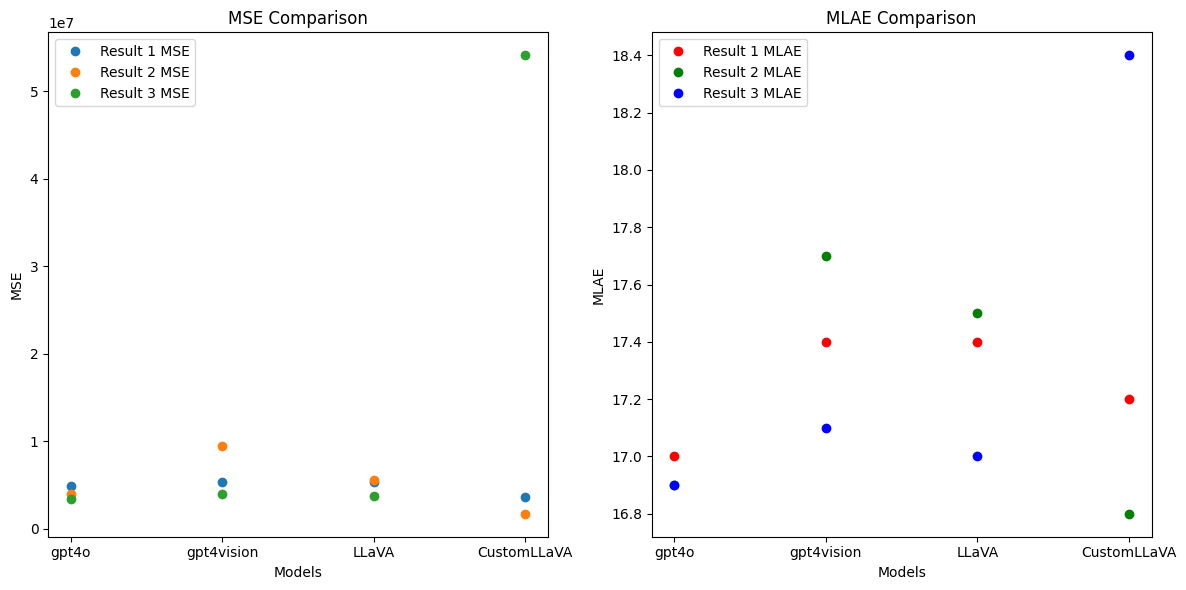

In [2]:
from plot_model_metrics import plot_charts_metrics

plot_charts_metrics(result1, result2, result3)